In [77]:
%load_ext autoreload
%autoreload 2

from glob import glob

import numpy as np
import pandas as pd
from rasterio.crs import CRS
from rasterio.enums import Resampling
from shapely.geometry import box
import skgstat as skg
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

import utils.rasters as rasters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
roi = box(-78.50261689364481, 42.26648164822645,
          -74.75627900301981, 43.29854299170165)

In [3]:
# Load defoliation data
files = list(glob("../Data/defoliation/*2021*.tif"))
tiles = rasters.filter_intersecting_rasters(files, roi, CRS.from_epsg('4326'))
vrts = rasters.open_rasters_as_vrt(tiles, CRS.from_epsg('5070'))
arr, trans = rasters.mosaic_rasters(vrts, roi, CRS.from_epsg(4326), 'max')

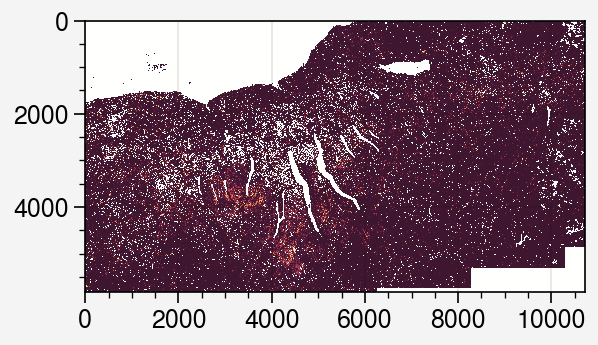

In [16]:
import ultraplot as uplt

fig, ax = uplt.subplots()
ax.imshow(arr.transpose([1, 2, 0]), vmin=20000, vmax=32000)

In [18]:
arr.shape

(1, 5820, 10725)

In [29]:
# Load defoliation data
files = list(glob("../Data/climate/*.tif"))
tiles = rasters.filter_intersecting_rasters(files, roi, CRS.from_epsg('4326'))
vrts = rasters.open_rasters_as_vrt(tiles, CRS.from_epsg('5070'), 
                                   resampling=Resampling.bilinear)
clim_arr, clim_trans = rasters.mosaic_rasters(vrts, roi, CRS.from_epsg(4326), 'max',
                                              height=arr.shape[1], width=arr.shape[2])

In [36]:
# Sample locations
coords = np.nonzero(arr[0])
indices = np.random.choice(np.arange(coords[0].shape[0]), 2000, replace=False)
sample = tuple(dim[indices] for dim in coords)

In [37]:
# Assemble sample dataset
defol = arr[(slice(None),) + sample]
clim = clim_arr[(slice(None),) + sample]
data = pd.DataFrame({'defol':defol[0], 'tmin':clim[0], 'tmax':clim[1], 'prcp':clim[2]})

In [49]:
# Train classifier on sample data
regr = linear_model.LinearRegression()
regr.fit(data[['tmin', 'tmax', 'prcp']], data['defol'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.27, 0.4 , 0.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['tmin','tmax','prcp']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.367e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [50]:
# Assemble full dataset
defol_full = arr[(slice(None),) + coords]
clim_full = clim_arr[(slice(None),) + coords]
all_data = pd.DataFrame({'defol':defol_full[0], 'tmin':clim_full[0], 'tmax':clim_full[1], 'prcp':clim_full[2]})

In [52]:
pred = regr.predict(all_data[['tmin', 'tmax', 'prcp']])
res = all_data['defol'] - pred

In [59]:
res_map = np.zeros(arr.shape[1:])

In [60]:
res_map.shape

(5820, 10725)

In [61]:
res_map[coords] = res

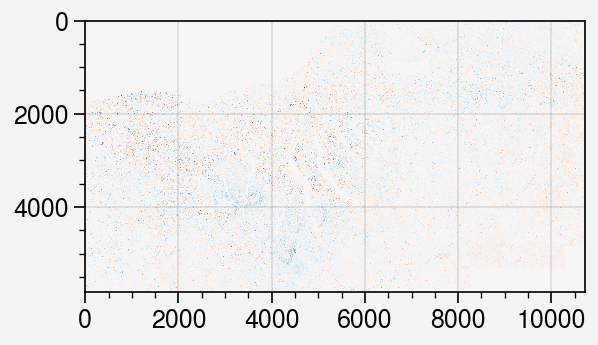

In [99]:
fig, ax = uplt.subplots()
ax.imshow(res_map)

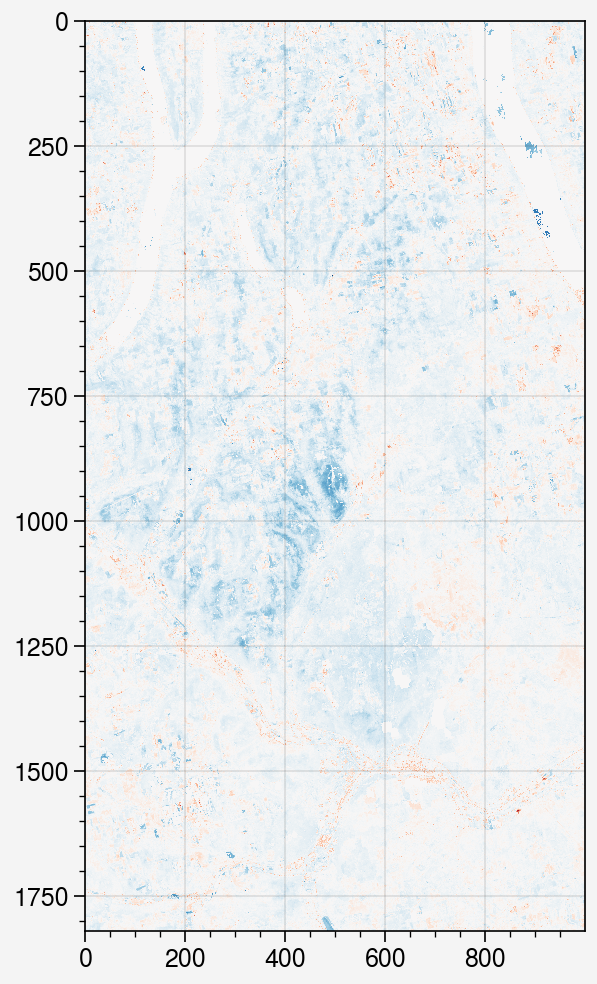

In [113]:
fig, ax = uplt.subplots()
ax.imshow(res_map[4000:6000, 4000:5000])

In [114]:
# Assemble semivarigram dataset
coords2 = np.nonzero(arr[0, 4000:6000, 4000:5000])
indices2 = np.random.choice(np.arange(coords2[0].shape[0]), 5000, replace=False)
sample2 = tuple(dim[indices2] for dim in coords2)
res_sample = res_map[4000:6000, 4000:5000][sample2]

In [115]:
xy = np.stack(sample2, axis=1)*30

In [116]:
res_sample

array([ -778.29641584,  3505.98692751,  1228.75229816, ...,
        -632.7311967 , -2626.56192625,   339.9095504 ], shape=(5000,))

In [117]:
V = skg.Variogram(xy, res_sample, model='spherical', n_lags=20)

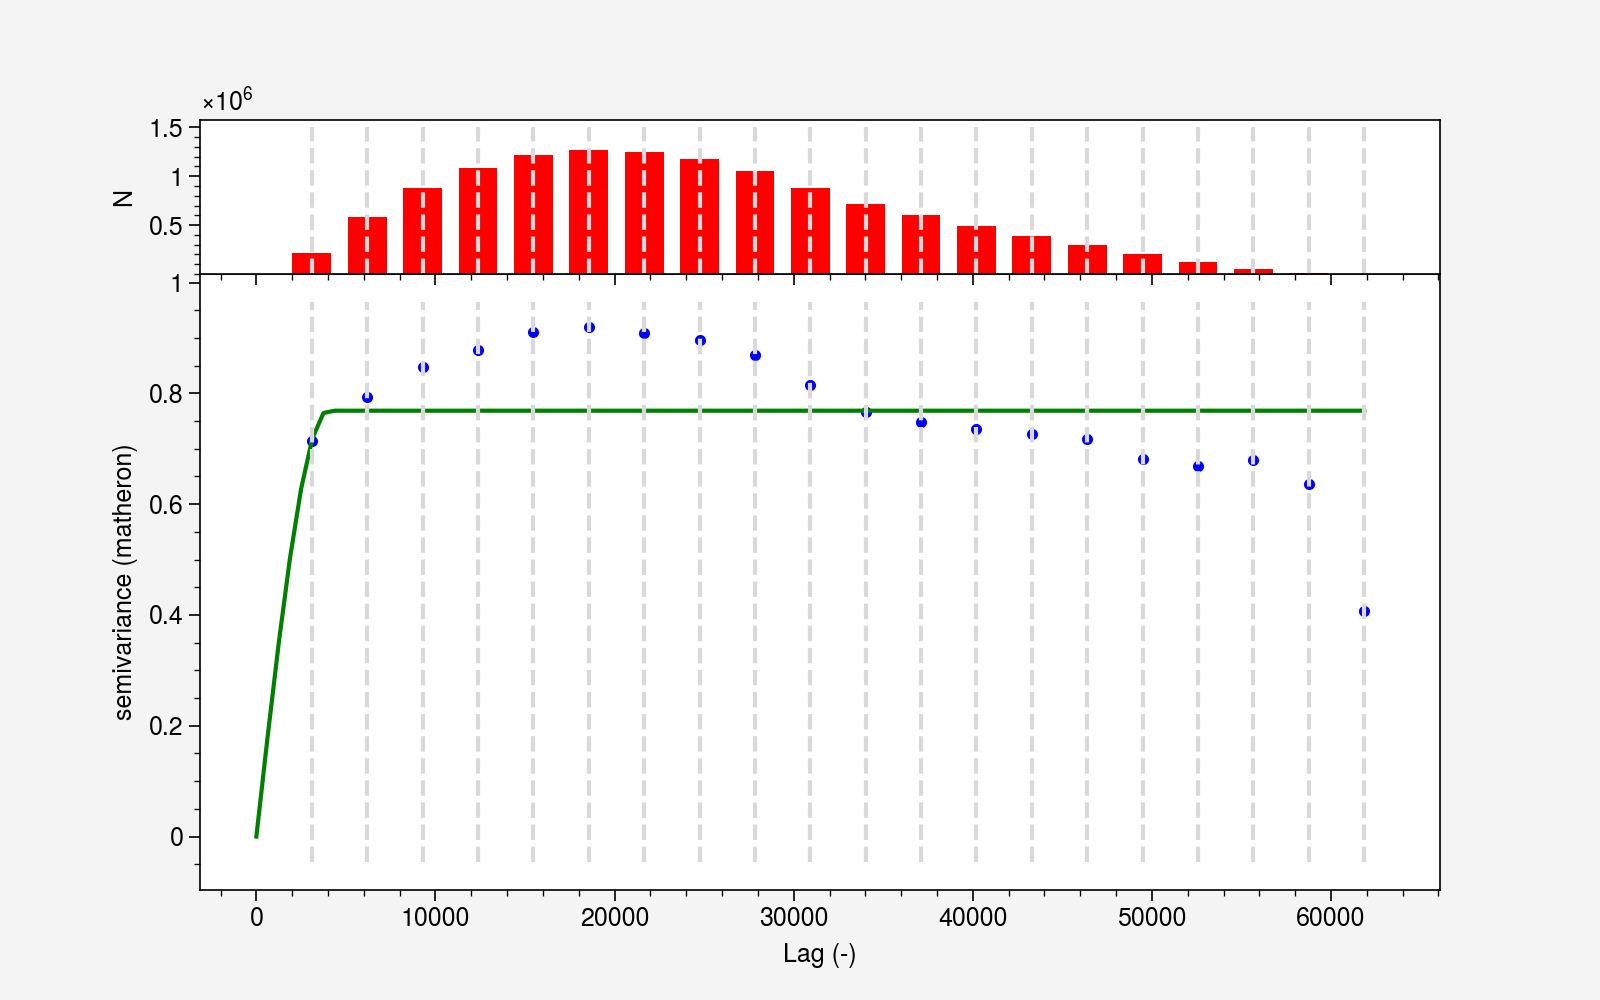

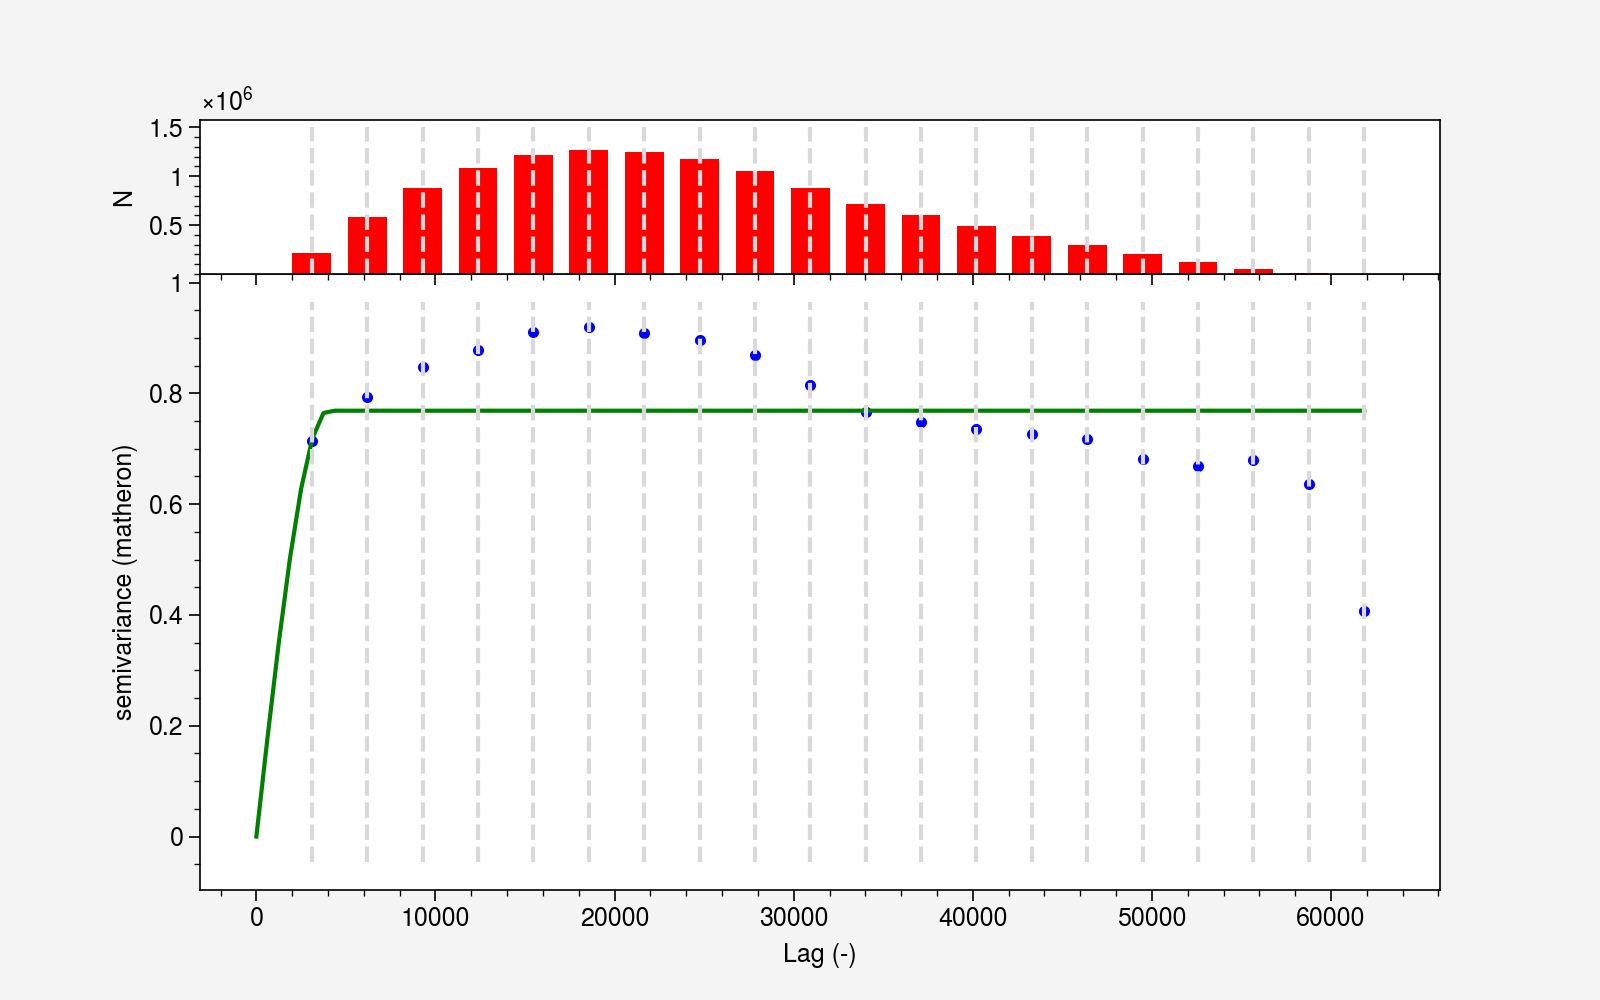

In [118]:
V.plot()